<a href="https://colab.research.google.com/github/yotart/Clustering/blob/main/Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#DATA

In [ ]:
import pandas as pd
df = pd.read_excel('https://raw.github.com/yotart/Clustering/main/clustering.xlsx')

In [ ]:
df.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Arrival Delay in Minutes,satisfaction,total_delay,travel_disctance_category,age_group,avg_service_score,avg_digital_score,avg_comfort_score,avg_airport_experience_score,delay_category
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,18.0,neutral or dissatisfied,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,6.0,neutral or dissatisfied,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,0.0,satisfied,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,9.0,neutral or dissatisfied,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,0.0,satisfied,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 33 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         103904 non-null  int64  
 1   id                                 103904 non-null  int64  
 2   Gender                             103904 non-null  object 
 3   Customer Type                      103904 non-null  object 
 4   Age                                103904 non-null  int64  
 5   Type of Travel                     103904 non-null  object 
 6   Class                              103904 non-null  object 
 7   Flight Distance                    103904 non-null  int64  
 8   Inflight wifi service              103904 non-null  int64  
 9   Departure/Arrival time convenient  103904 non-null  int64  
 10  Ease of Online booking             103904 non-null  int64  
 11  Gate location                      1039

#DATA PREPARATION

##Checking Duplicate

In [ ]:
df.duplicated().sum()

np.int64(0)

##Checking Data NA

In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
id,0
Gender,0
Customer Type,0
Age,0
Type of Travel,0
Class,0
Flight Distance,0
Inflight wifi service,0
Departure/Arrival time convenient,0


In [ ]:
df['Arrival Delay in Minutes'] = df['Arrival Delay in Minutes'].fillna(df['Departure Delay in Minutes'])

##Feature Engineering

In [ ]:
df.describe()

,Unnamed: 0,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,...,Departure Delay in Minutes,Arrival Delay in Minutes,total_delay,travel_disctance_category,age_group,avg_service_score,avg_digital_score,avg_comfort_score,avg_airport_experience_score,delay_category
count,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,...,103904.000000,103904.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,51951.500000,64924.210502,39.379706,1189.448375,2.729683,3.060296,2.756901,2.976883,3.202129,3.250375,...,14.815618,15.245072,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,29994.645522,37463.812252,15.114964,997.147281,1.327829,1.525075,1.398929,1.277621,1.329533,1.349509,...,38.230901,38.808674,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,7.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,25975.750000,32533.750000,27.000000,414.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,...,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,51951.500000,64856.500000,40.000000,843.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,...,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,77927.250000,97368.250000,51.000000,1743.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,...,12.000000,13.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,103903.000000,129880.000000,85.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,...,1592.000000,1584.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
#Total Delay
df['total_delay']=df['Departure Delay in Minutes']+df['Arrival Delay in Minutes']

#Travel Distance Category
def jarak (dist):
  if dist < 1000:
    return 'Short'
  elif dist <= 2500:
    return 'Medium'
  else:
    return 'Long'
df['travel_disctance_category']=df['Flight Distance'].apply(jarak)

#Age Group
def umur(age):
  if age < 25:
    return 'Young'
  elif age <= 45:
    return 'Middle'
  else:
    return 'Old'
df['age_group']=df['Age'].apply(umur)

#Average Service Score
df['avg_service_score']=(df['Inflight wifi service']+df['Inflight service']+df['Leg room service']+df['On-board service']+df['Checkin service'])/5

#Average Digital Score
df['avg_digital_score']=(df['Ease of Online booking']+df['Online boarding'])/2

#Average Ccomfort Score
df['avg_comfort_score']=(df['Cleanliness']+df['Departure/Arrival time convenient']+df['Inflight entertainment']+df['Food and drink'])/4

#Average Airport Experience Score
df['avg_airport_experience_score']=(df['Gate location']+df['Baggage handling'])/2

#Delay Category
def terlambat(delay):
  if delay == 0:
    return 'Ontime'
  elif delay <= 60:
    return 'Low'
  elif delay <= 180:
    return 'Medium'
  else:
    return 'High'

df['delay_category'] = df['total_delay'].apply(terlambat)

In [ ]:
df.describe()

,Unnamed: 0,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,...,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,total_delay,avg_service_score,avg_digital_score,avg_comfort_score,avg_airport_experience_score
count,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,...,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000
mean,51951.500000,64924.210502,39.379706,1189.448375,2.729683,3.060296,2.756901,2.976883,3.202129,3.250375,...,3.304290,3.640428,3.286351,14.815618,15.245072,30.060691,3.281564,3.003638,3.226733,3.304358
std,29994.645522,37463.812252,15.114964,997.147281,1.327829,1.525075,1.398929,1.277621,1.329533,1.349509,...,1.265396,1.175663,1.312273,38.230901,38.808674,76.377742,0.790657,1.151505,0.954325,0.870895
min,0.000000,1.000000,7.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.600000,0.000000,0.250000,0.500000
25%,25975.750000,32533.750000,27.000000,414.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,...,3.000000,3.000000,2.000000,0.000000,0.000000,0.000000,2.800000,2.000000,2.500000,2.500000
50%,51951.500000,64856.500000,40.000000,843.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,...,3.000000,4.000000,3.000000,0.000000,0.000000,2.000000,3.400000,3.000000,3.250000,3.500000
75%,77927.250000,97368.250000,51.000000,1743.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,...,4.000000,5.000000,4.000000,12.000000,13.000000,24.000000,3.800000,4.000000,4.000000,4.000000
max,103903.000000,129880.000000,85.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,1592.000000,1584.000000,3176.000000,5.000000,5.000000,5.000000,5.000000


In [ ]:
df.head(3)

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Arrival Delay in Minutes,satisfaction,total_delay,travel_disctance_category,age_group,avg_service_score,avg_digital_score,avg_comfort_score,avg_airport_experience_score,delay_category
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,18.0,neutral or dissatisfied,43.0,Short,Young,3.8,3.0,4.75,2.5,Low
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,6.0,neutral or dissatisfied,7.0,Short,Middle,2.8,3.0,1.25,3.0,Low
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,0.0,satisfied,0.0,Medium,Middle,3.4,3.5,4.25,3.0,Ontime


In [ ]:
df['delay_category'].value_counts()

,count
delay_category,
Ontime,47575
Low,42009
Medium,10151
High,4169


In [ ]:
df['travel_disctance_category'].value_counts()

,count
travel_disctance_category,
Short,60054
Medium,30021
Long,13829


In [ ]:
df['age_group'].value_counts()

,count
age_group,
Middle,46194
Old,37895
Young,19815


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 33 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         103904 non-null  int64  
 1   id                                 103904 non-null  int64  
 2   Gender                             103904 non-null  object 
 3   Customer Type                      103904 non-null  object 
 4   Age                                103904 non-null  int64  
 5   Type of Travel                     103904 non-null  object 
 6   Class                              103904 non-null  object 
 7   Flight Distance                    103904 non-null  int64  
 8   Inflight wifi service              103904 non-null  int64  
 9   Departure/Arrival time convenient  103904 non-null  int64  
 10  Ease of Online booking             103904 non-null  int64  
 11  Gate location                      1039

##Checking Consistency

In [ ]:
df['Gender'].unique()

array(['Male', 'Female'], dtype=object)

In [ ]:
df['Customer Type'].unique()

array(['Loyal Customer', 'disloyal Customer'], dtype=object)

In [ ]:
df['Customer Type'] = df['Customer Type'].str.strip().str.title()

In [ ]:
df['Type of Travel'].unique()

array(['Personal Travel', 'Business travel'], dtype=object)

In [ ]:
df['Type of Travel'] = df['Type of Travel'].str.strip().str.title()

In [ ]:
df['Class'].unique()

array(['Eco Plus', 'Business', 'Eco'], dtype=object)

In [ ]:
df['satisfaction'].unique()

array(['neutral or dissatisfied', 'satisfied'], dtype=object)

In [ ]:
df['satisfaction'] = df['satisfaction'].str.strip().str.title()

In [ ]:
df.describe()

,Unnamed: 0,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,...,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,total_delay,avg_service_score,avg_digital_score,avg_comfort_score,avg_airport_experience_score
count,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,...,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000
mean,51951.500000,64924.210502,39.379706,1189.448375,2.729683,3.060296,2.756901,2.976883,3.202129,3.250375,...,3.304290,3.640428,3.286351,14.815618,15.245072,30.060691,3.281564,3.003638,3.226733,3.304358
std,29994.645522,37463.812252,15.114964,997.147281,1.327829,1.525075,1.398929,1.277621,1.329533,1.349509,...,1.265396,1.175663,1.312273,38.230901,38.808674,76.377742,0.790657,1.151505,0.954325,0.870895
min,0.000000,1.000000,7.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.600000,0.000000,0.250000,0.500000
25%,25975.750000,32533.750000,27.000000,414.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,...,3.000000,3.000000,2.000000,0.000000,0.000000,0.000000,2.800000,2.000000,2.500000,2.500000
50%,51951.500000,64856.500000,40.000000,843.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,...,3.000000,4.000000,3.000000,0.000000,0.000000,2.000000,3.400000,3.000000,3.250000,3.500000
75%,77927.250000,97368.250000,51.000000,1743.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,...,4.000000,5.000000,4.000000,12.000000,13.000000,24.000000,3.800000,4.000000,4.000000,4.000000
max,103903.000000,129880.000000,85.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,1592.000000,1584.000000,3176.000000,5.000000,5.000000,5.000000,5.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 33 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         103904 non-null  int64  
 1   id                                 103904 non-null  int64  
 2   Gender                             103904 non-null  object 
 3   Customer Type                      103904 non-null  object 
 4   Age                                103904 non-null  int64  
 5   Type of Travel                     103904 non-null  object 
 6   Class                              103904 non-null  object 
 7   Flight Distance                    103904 non-null  int64  
 8   Inflight wifi service              103904 non-null  int64  
 9   Departure/Arrival time convenient  103904 non-null  int64  
 10  Ease of Online booking             103904 non-null  int64  
 11  Gate location                      1039

In [ ]:
df.columns=['no','id','gender','customer type','age','type of travel','class','flight distance',
            'inflight wifi service','departure/arrival time convenient','ease of online booking',
            'gate location','food and drink','online boarding','seat comfort','inflight entertainment',
            'on-board service','leg room service','baggage handling','checkin service','inflight service',
            'cleanliness','departure delay in minutes','arrival delay in minutes','satisfaction','total delay',
            'travel distance category','age group','avg service score','avg digital score','avg comfort score',
            'avg airport experience score','delay category']

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 33 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   no                                 103904 non-null  int64  
 1   id                                 103904 non-null  int64  
 2   gender                             103904 non-null  object 
 3   customer type                      103904 non-null  object 
 4   age                                103904 non-null  int64  
 5   type of travel                     103904 non-null  object 
 6   class                              103904 non-null  object 
 7   flight distance                    103904 non-null  int64  
 8   inflight wifi service              103904 non-null  int64  
 9   departure/arrival time convenient  103904 non-null  int64  
 10  ease of online booking             103904 non-null  int64  
 11  gate location                      1039

In [ ]:
df.to_csv('maskapai.csv',index=False)

In [ ]:
from sqlalchemy import create_engine
from urllib.parse import quote_plus

username = "postgres.dbamclthcwanalmrwrhw"
password = quote_plus("Supabase_MyProject")
host = "aws-1-ap-northeast-1.pooler.supabase.com"
port = "6543"
database = "postgres"

DATABASE_URL = (
    f"postgresql://{username}:{password}@{host}:{port}/{database}"
)

engine = create_engine(DATABASE_URL)

In [ ]:
df.to_sql("maskapai",engine,schema='public',if_exists="replace",index=False,chunksize=1000)

1934

#Clustering

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [ ]:
numeric_cols = [
    'age', 'flight distance', 'inflight wifi service', 'departure/arrival time convenient',
    'ease of online booking', 'gate location', 'food and drink', 'online boarding',
    'seat comfort', 'inflight entertainment', 'on-board service', 'leg room service',
    'baggage handling', 'checkin service', 'inflight service', 'cleanliness',
    'departure delay in minutes', 'arrival delay in minutes', 'total delay', 'avg service score',
    'avg digital score', 'avg comfort score', 'avg airport experience score'
]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col]).fillna(0)

##Encode

In [ ]:
fitur_dipilih = numeric_cols + ['gender', 'customer type', 'type of travel', 'class','satisfaction','travel distance category','age group','delay category']
df_model = df[fitur_dipilih].copy()

class_map = {'Eco': 0, 'Eco Plus': 1, 'Business': 2}
df_model['class'] = df_model['class'].map(class_map)

df_encoded = pd.get_dummies(df_model, columns=['gender', 'customer type', 'type of travel', 'satisfaction', 'travel distance category', 'age group', 'delay category'], drop_first=True, dtype=int)

print("\n1. Proses Encoding Selesai. Dimensi Data Saat Ini:", df_encoded.shape)


1. Proses Encoding Selesai. Dimensi Data Saat Ini: (103904, 35)


##Cek Multikolinearitas

In [ ]:
vif_data = pd.DataFrame()
vif_data["Fitur"] = df_encoded.columns
vif_data["VIF"] = [variance_inflation_factor(df_encoded.values, i) for i in range(df_encoded.shape[1])]

print("\n2. Hasil Uji VIF (Sebelum PCA):")
print(vif_data.sort_values(by="VIF", ascending=False).to_string(index=False))

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)



2. Hasil Uji VIF (Sebelum PCA):
                            Fitur       VIF
            inflight wifi service       inf
           ease of online booking       inf
departure/arrival time convenient       inf
                avg comfort score       inf
                avg digital score       inf
                    gate location       inf
                   food and drink       inf
                  online boarding       inf
           inflight entertainment       inf
                 on-board service       inf
                 leg room service       inf
                      cleanliness       inf
                 baggage handling       inf
                  checkin service       inf
                 inflight service       inf
         arrival delay in minutes       inf
       departure delay in minutes       inf
                      total delay       inf
                avg service score       inf
     avg airport experience score       inf
                              age 39.262270

In [ ]:
####percobaaan
import numpy as np
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# =====================================================================
# KODE SELEKSI VIF ITERATIF (LANGSUNG JALAN)
# =====================================================================

# 1. Salin data df_encoded Anda ke variabel baru untuk proses eliminasi
df_vif_clean = df_encoded.copy()

print("--- Memulai Proses Eliminasi Fitur Berdasarkan VIF > 10 ---\n")

while True:
    # Hitung VIF untuk fitur yang tersisa di dalam loop
    vif_list = []
    for i in range(df_vif_clean.shape[1]):
        try:
            vif_val = variance_inflation_factor(df_vif_clean.values, i)
        except Exception:
            vif_val = 999999
        vif_list.append(vif_val)

    # Buat dataframe sementara untuk pengecekan nilai tertinggi
    temp_vif = pd.DataFrame({
        "Fitur": df_vif_clean.columns,
        "VIF": vif_list
    })

    # Ganti nilai 'inf' menjadi angka sangat besar agar bisa diurutkan dan dideteksi
    temp_vif["VIF"] = temp_vif["VIF"].replace([np.inf, -np.inf], 999999)

    # Cari fitur dengan nilai VIF tertinggi saat ini
    max_row = temp_vif.loc[temp_vif["VIF"].idxmax()]
    max_vif = max_row["VIF"]
    max_feature = max_row["Fitur"]

    # Cek Kondisi: Jika VIF tertinggi masih >= 10, hapus fitur tersebut
    if max_vif >= 10:
        if max_vif == 999999:
            print(f"Menghapus: {max_feature:<35} | VIF: inf")
        else:
            print(f"Menghapus: {max_feature:<35} | VIF: {max_vif:.2f}")

        # Drop fitur dari dataframe
        df_vif_clean = df_vif_clean.drop(columns=[max_feature])
    else:
        # Jika nilai maks sudah di bawah 10, hentikan perulangan
        break

print("\n--- Proses Eliminasi Selesai ---")

# =====================================================================
# 2. MENAMPILKAN HASIL AKHIR (VIF SEBELUM PCA YANG SUDAH BERSIH)
# =====================================================================

# Hitung ulang VIF final untuk memastikan
vif_final = pd.DataFrame()
vif_final["Fitur"] = df_vif_clean.columns
vif_final["VIF"] = [
    variance_inflation_factor(df_vif_clean.values, i)
    for i in range(df_vif_clean.shape[1])
]

print("\n2. Hasil Uji VIF (Sebelum PCA - Sudah Disaring < 10):")
print(vif_final.sort_values(by="VIF", ascending=False).to_string(index=False))

--- Memulai Proses Eliminasi Fitur Berdasarkan VIF > 10 ---



/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Menghapus: inflight wifi service               | VIF: inf


/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Menghapus: departure/arrival time convenient   | VIF: inf


...

Menghapus: ease of online booking              | VIF: inf


/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Menghapus: gate location                       | VIF: inf


/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Menghapus: departure delay in minutes          | VIF: inf
Menghapus: avg service score                   | VIF: 406.90
Menghapus: avg comfort score                   | VIF: 129.45
Menghapus: total delay                         | VIF: 70.83
Menghapus: age                                 | VIF: 39.16
Menghapus: avg airport experience score        | VIF: 38.10
Menghapus: online boarding                     | VIF: 29.02
Menghapus: inflight entertainment              | VIF: 27.73
Menghapus: delay category_Ontime               | VIF: 25.06
Menghapus: inflight service                    | VIF: 20.37
Menghapus: cleanliness                         | VIF: 17.25
Menghapus: baggage handling                    | VIF: 15.44
Menghapus: seat comfort                        | VIF: 13.40
Menghapus: travel distance category_Short      | VIF: 10.74

--- Proses Eliminasi Selesai ---

2. Hasil Uji VIF (Sebelum PCA - Sudah Disaring < 10):
                          Fitur      VIF
               on-board servic

##Scalling

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_vif_clean)

print("\n3. Proses Scaling Selesai (Rata-rata ~ 0, Standar Deviasi = 1).")


3. Proses Scaling Selesai (Rata-rata ~ 0, Standar Deviasi = 1).


##PCA

In [ ]:
pca = PCA(n_components=0.85, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("\n4. Proses PCA Selesai:")
print(f"   - Jumlah fitur asli sebelum PCA: {df_vif_clean.shape[1]}")
print(f"   - Jumlah komponen baru setelah PCA: {X_pca.shape[1]}")
print(f"   - Total informasi (varians) yang dipertahankan: {sum(pca.explained_variance_ratio_)*100:.2f}%")


4. Proses PCA Selesai:
   - Jumlah fitur asli sebelum PCA: 17
   - Jumlah komponen baru setelah PCA: 12
   - Total informasi (varians) yang dipertahankan: 85.77%


In [ ]:
from sklearn.decomposition import PCA
pca = PCA()
pca.fit(X_scaled)
pca.explained_variance_ratio_

array([0.17591288, 0.09154666, 0.08780112, 0.07906706, 0.0683001 ,
       0.06263221, 0.05876589, 0.05098413, 0.05045878, 0.04826405,
       0.04564785, 0.03830373, 0.03626036, 0.03542179, 0.03157357,
       0.02409034, 0.01496948])

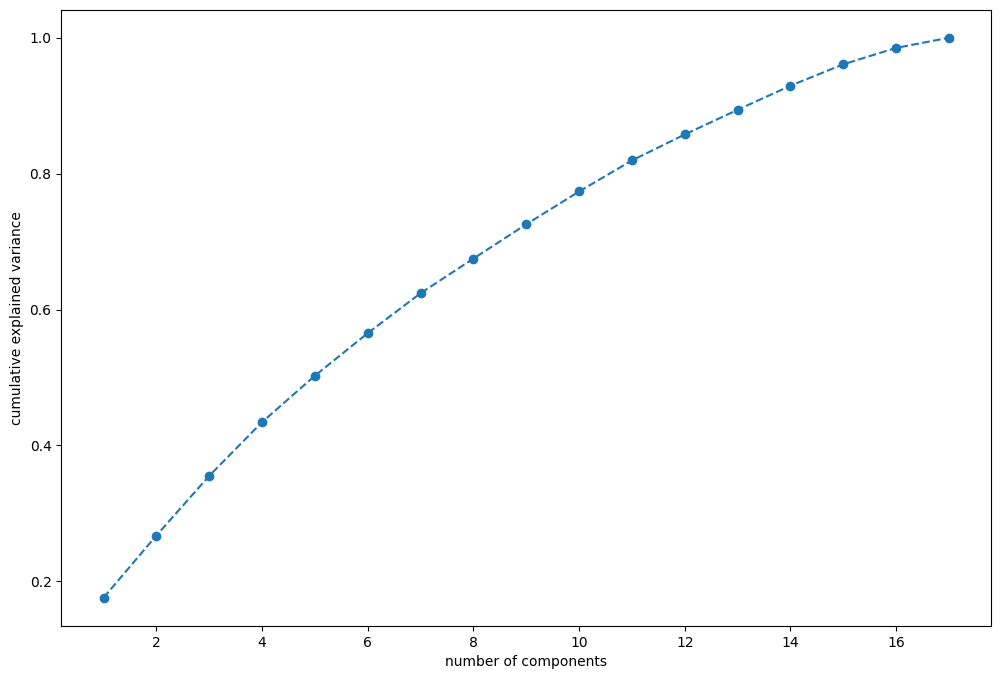

In [ ]:
plt.figure(figsize=(12,8))
plt.plot(range(1,len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_.cumsum(), marker='o', linestyle='--')
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance')
plt.show()

##Elbow Method

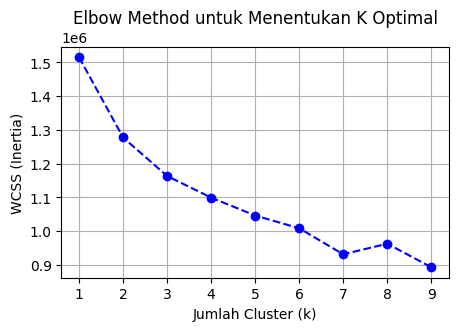

In [ ]:
wcss = []
K_range = range(1, 10)
for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(X_pca)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(5, 3))
plt.plot(K_range, wcss, marker='o', linestyle='--', color='b')
plt.title('Elbow Method untuk Menentukan K Optimal')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(K_range)
plt.grid(True)
plt.show()

##Silhouette

Jumlah Cluster (k) = 2 | Silhouette Score = 0.1518
Jumlah Cluster (k) = 3 | Silhouette Score = 0.1656
Jumlah Cluster (k) = 4 | Silhouette Score = 0.1440
Jumlah Cluster (k) = 5 | Silhouette Score = 0.1351


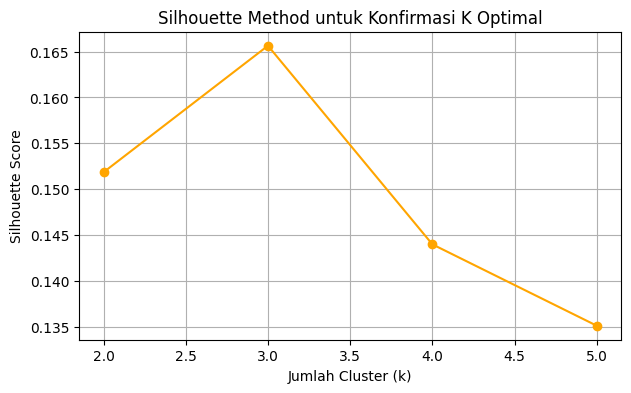

In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

silhouette_avg = []
K_range = range(2, 6)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    cluster_labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, cluster_labels)
    silhouette_avg.append(score)
    print(f"Jumlah Cluster (k) = {k} | Silhouette Score = {score:.4f}")

plt.figure(figsize=(7, 4))
plt.plot(K_range, silhouette_avg, marker='o', color='orange', linestyle='-')
plt.title('Silhouette Method untuk Konfirmasi K Optimal')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

##K-Means

In [ ]:
kmeans_pca = KMeans(n_clusters=3, init='k-means++', random_state=42)
kmeans_pca.fit(X_pca)

KMeans(n_clusters=3, random_state=42)

In [ ]:
pca_column_names = [f'PC{i+1}' for i in range(X_pca.shape[1])]
df_pca_components = pd.DataFrame(X_pca, columns=pca_column_names)

df_segm_pca = pd.concat([df.reset_index(drop=True), df_pca_components], axis=1)
df_segm_pca['K-means PCA'] = kmeans_pca.labels_
df_segm_pca

,no,id,gender,customer type,age,type of travel,class,flight distance,inflight wifi service,departure/arrival time convenient,...,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,K-means PCA
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,1.732066,0.769689,1.376365,1.212237,0.615966,0.959342,-0.308280,-0.684603,0.413885,2
1,1,5047,Male,Disloyal Customer,25,Business Travel,Business,235,3,2,...,-1.760087,-1.090108,-2.135249,0.969742,-0.231708,1.257638,-0.194815,0.914971,-0.286463,0
2,2,110028,Female,Loyal Customer,26,Business Travel,Business,1142,2,2,...,-0.085088,0.425358,1.500765,-0.724115,-0.101641,-1.059022,0.757232,0.065590,-0.265699,1
3,3,24026,Female,Loyal Customer,25,Business Travel,Business,562,2,5,...,-1.399122,-0.641423,-0.853870,-0.844077,-0.876426,2.082450,-0.046013,0.070398,-0.156007,2
4,4,119299,Male,Loyal Customer,61,Business Travel,Business,214,3,3,...,-0.007050,-1.804762,0.162399,1.186858,-0.755649,-0.099566,0.001151,0.482324,-0.388388,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103899,103899,94171,Female,Disloyal Customer,23,Business Travel,Eco,192,2,1,...,-0.844562,-0.412602,-0.110555,-0.898454,0.296059,0.285799,-0.381996,0.020966,0.991307,0
103900,103900,73097,Male,Loyal Customer,49,Business Travel,Business,2347,4,4,...,0.555020,0.985115,-1.303152,0.434515,-0.281556,-1.237091,-0.381077,1.092631,-0.261310,1
103901,103901,68825,Male,Disloyal Customer,30,Business Travel,Business,1995,1,1,...,-1.236558,1.209526,-0.562587,0.967478,2.698039,-1.704830,0.713332,-0.767441,0.007078,0
103902,103902,54173,Female,Disloyal Customer,22,Business Travel,Eco,1000,1,1,...,1.305595,1.818539,-1.684847,-1.494223,0.085207,-1.772486,0.432900,0.792773,-0.681153,0


In [ ]:
# 1. Rename kolom dengan aman
df_segm_pca = df_segm_pca.rename(columns={"K-means PCA": "Segment"})

# 2. Ganti nilai di dalamnya tanpa inplace=True
df_segm_pca["Segment"] = df_segm_pca["Segment"].replace({
    0: "Puas",
    1: "Tidak Puas",
    2: "Cukup Puas"
})

df_segm_pca.head()

,no,id,gender,customer type,age,type of travel,class,flight distance,inflight wifi service,departure/arrival time convenient,...,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,Segment
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,1.732066,0.769689,1.376365,1.212237,0.615966,0.959342,-0.308280,-0.684603,0.413885,Cukup Puas
1,1,5047,Male,Disloyal Customer,25,Business Travel,Business,235,3,2,...,-1.760087,-1.090108,-2.135249,0.969742,-0.231708,1.257638,-0.194815,0.914971,-0.286463,Puas
2,2,110028,Female,Loyal Customer,26,Business Travel,Business,1142,2,2,...,-0.085088,0.425358,1.500765,-0.724115,-0.101641,-1.059022,0.757232,0.065590,-0.265699,Tidak Puas
3,3,24026,Female,Loyal Customer,25,Business Travel,Business,562,2,5,...,-1.399122,-0.641423,-0.853870,-0.844077,-0.876426,2.082450,-0.046013,0.070398,-0.156007,Cukup Puas
4,4,119299,Male,Loyal Customer,61,Business Travel,Business,214,3,3,...,-0.007050,-1.804762,0.162399,1.186858,-0.755649,-0.099566,0.001151,0.482324,-0.388388,Tidak Puas


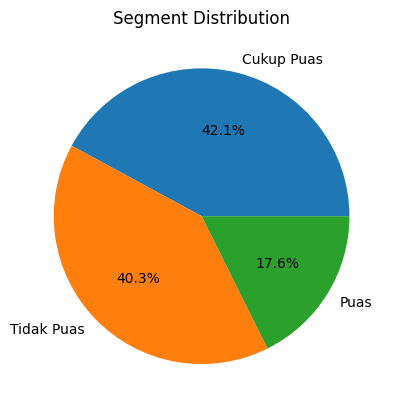

In [ ]:
import matplotlib.pyplot as plt
percent_countries = df_segm_pca['Segment'].value_counts(normalize=True) * 100
fig, ax = plt.subplots()
ax.pie(percent_countries, labels=percent_countries.index, autopct='%1.1f%%')

ax.set_title('Segment Distribution')
plt.show()

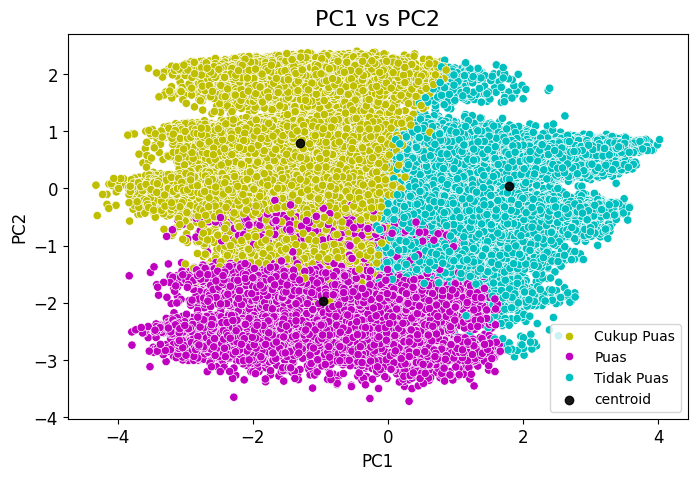

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Menggunakan warna yang lebih terang
plt.figure(figsize=(8, 5))
sns.scatterplot(
    x=df_segm_pca['PC1'],
    y=df_segm_pca['PC2'],
    hue=df_segm_pca['Segment'],
    palette=['y','m','c'] # Changed to 3 colors to match the 3 segments
)
centers=np.array(kmeans_pca.cluster_centers_)
plt.scatter(centers[:,0],centers[:,1],color='black',alpha=0.9,label = 'centroid')
plt.title('PC1 vs PC2', fontsize=16)
plt.xlabel('PC1', fontsize=12)
plt.ylabel('PC2', fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend()
plt.show()

In [ ]:
df['cluster'] = kmeans_pca.labels_
df

,no,id,gender,customer type,age,type of travel,class,flight distance,inflight wifi service,departure/arrival time convenient,...,satisfaction,total delay,travel distance category,age group,avg service score,avg digital score,avg comfort score,avg airport experience score,delay category,cluster
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,Neutral Or Dissatisfied,43.0,Short,Young,3.8,3.0,4.75,2.5,Low,2
1,1,5047,Male,Disloyal Customer,25,Business Travel,Business,235,3,2,...,Neutral Or Dissatisfied,7.0,Short,Middle,2.8,3.0,1.25,3.0,Low,0
2,2,110028,Female,Loyal Customer,26,Business Travel,Business,1142,2,2,...,Satisfied,0.0,Medium,Middle,3.4,3.5,4.25,3.0,Ontime,1
3,3,24026,Female,Loyal Customer,25,Business Travel,Business,562,2,5,...,Neutral Or Dissatisfied,20.0,Short,Middle,2.8,3.5,2.75,4.0,Low,2
4,4,119299,Male,Loyal Customer,61,Business Travel,Business,214,3,3,...,Satisfied,0.0,Short,Old,3.2,4.0,3.25,3.5,Ontime,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103899,103899,94171,Female,Disloyal Customer,23,Business Travel,Eco,192,2,1,...,Neutral Or Dissatisfied,3.0,Short,Young,2.2,2.0,1.75,3.5,Low,0
103900,103900,73097,Male,Loyal Customer,49,Business Travel,Business,2347,4,4,...,Satisfied,0.0,Medium,Old,4.8,4.0,3.75,4.5,Ontime,1
103901,103901,68825,Male,Disloyal Customer,30,Business Travel,Business,1995,1,1,...,Neutral Or Dissatisfied,21.0,Medium,Middle,3.2,1.0,3.25,3.5,Low,0
103902,103902,54173,Female,Disloyal Customer,22,Business Travel,Eco,1000,1,1,...,Neutral Or Dissatisfied,0.0,Medium,Young,3.8,1.0,1.00,3.0,Ontime,0


In [ ]:
def highlight_max_min(s):
  is_max = s == s.max()
  is_min = s == s.min()
  return ['background-color: red' if v else 'background-color: lightgreen'
          if is_min[i]  else '' for i, v in enumerate(is_max)]
profil = df.groupby('cluster').mean(numeric_only=True).round(2).T
profil_styled = profil.style.apply(highlight_max_min, axis=1)
profil_styled

cluster,0,1,2
no,51742.940000,51993.980000,51998.290000
id,64303.500000,66459.340000,63715.820000
age,29.900000,43.770000,39.150000
flight distance,694.640000,1826.080000,787.830000
inflight wifi service,2.640000,3.030000,2.480000
departure/arrival time convenient,2.330000,3.020000,3.410000
ease of online booking,2.630000,3.040000,2.540000
gate location,3.000000,3.040000,2.910000
food and drink,3.010000,3.530000,2.970000
online boarding,2.640000,4.030000,2.760000


##DBSCAN

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.model_selection import train_test_split
#for eps in [2,3,3.5,4,5,6]:
  #db = DBSCAN(eps=eps, min_samples=5)
  #labels = db.fit_predict(X_scaled)
  #n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
  #n_noise = list(labels).count(-1)
  #print(f'eps: {eps}, clusters: {n_clusters}, noise: {n_noise}')

#X_sample, _ = train_test_split(X_pca, train_size=0.10, random_state=42)

# Jalankan loop dengan data sample yang lebih kecil
#for eps in [2, 3, 3.5, 4, 5, 6]:
    # Gunakan n_jobs=-1 untuk mempercepat proses menggunakan semua core CPU
    #db = DBSCAN(eps=eps, min_samples=5, n_jobs=-1)
    #labels = db.fit_predict(X_pca) # Menggunakan X_sample, bukan X_scaled

    #n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    #n_noise = np.sum(labels == -1) # Menggunakan numpy jauh lebih cepat daripada list().count()

    #print(f'eps: {eps}, clusters: {n_clusters}, noise: {n_noise}')

In [ ]:
db = DBSCAN(eps=3, min_samples=5)
labels = db.fit_predict(X_pca)
pd.Series(labels).value_counts().sort_index()

,count
-1,27
0,103877


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

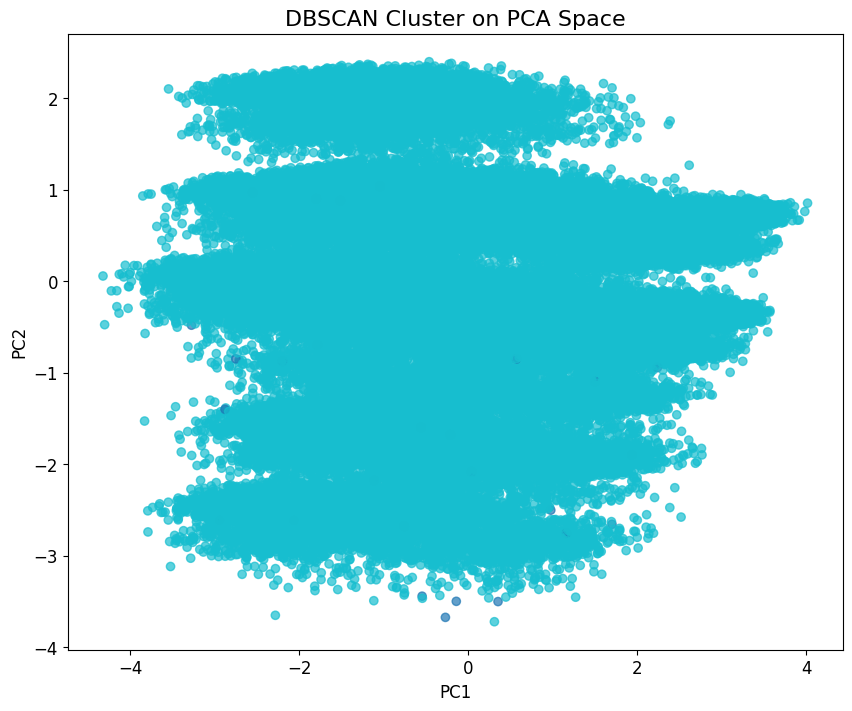

In [ ]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=labels,
    cmap='tab10',
    alpha=0.7

)
plt.title('DBSCAN Cluster on PCA Space', fontsize=16)
plt.xlabel('PC1', fontsize=12)
plt.ylabel('PC2', fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt

##Hierarchy

In [ ]:
from sklearn.model_selection import train_test_split
X_sample, _ = train_test_split(X_pca, train_size=0.10, random_state=42)

In [ ]:
from sklearn.cluster import AgglomerativeClustering

model = AgglomerativeClustering(n_clusters=3, metric='euclidean',
                                memory=None, connectivity=None,
                                compute_full_tree='auto', linkage='ward',
                                )
model.fit(X_sample)

AgglomerativeClustering(n_clusters=3)

In [ ]:
df_hc = pd.DataFrame(X_sample)
df_hc['hc PCA'] = model.labels_
df_hc

,0,1,2,3,4,5,6,7,8,9,10,11,hc PCA
0,0.032854,-1.448721,1.493342,-0.959050,2.384397,0.538417,1.244831,-0.696298,1.822073,0.823251,0.550183,-1.906702,2
1,2.167859,-0.920426,3.202778,0.459037,1.573133,-0.709327,-1.291236,-0.239290,0.594951,0.310540,0.431609,1.203647,2
2,0.018116,-0.339045,-0.077078,0.455161,-0.906101,-0.008752,-0.679203,-1.736060,0.711285,1.883684,-0.542040,-0.000603,0
3,0.119128,0.733196,0.277130,-0.235144,-1.714101,-1.139648,-1.187517,-2.076685,0.760491,-0.054589,1.500453,0.126783,1
4,-1.262590,0.049018,-1.440328,1.394993,2.487701,1.129148,-0.854567,0.205611,1.039144,1.703514,0.203053,0.070630,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10385,-1.188963,-1.425560,-1.198207,-0.037123,-1.040108,-0.918104,0.937828,1.017418,0.101567,0.316488,0.612703,0.658720,0
10386,-2.127719,0.304305,-1.447057,1.482619,0.979737,0.721658,0.876028,0.341156,0.309706,-1.288741,-0.483670,1.325365,0
10387,-1.367959,0.565503,4.138913,-1.500945,1.525809,-2.202982,0.505968,1.847534,2.309113,0.483786,1.219384,-3.068648,2
10388,-0.407199,-0.176085,0.144913,-1.455575,-1.931791,2.744728,-0.196165,-1.513420,0.717766,0.041938,0.848712,-0.445300,0


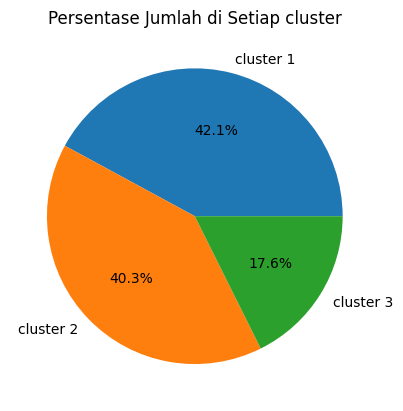

In [ ]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax.pie(percent_countries, labels=['cluster 1', 'cluster 2', 'cluster 3'], autopct='%1.1f%%')
ax.set_title('Persentase Jumlah di Setiap cluster')
plt.show()

/tmp/ipykernel_46661/35724838.py:3: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  sns.scatterplot(x=1, y=2, data=df_hc, hue='hc PCA',


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

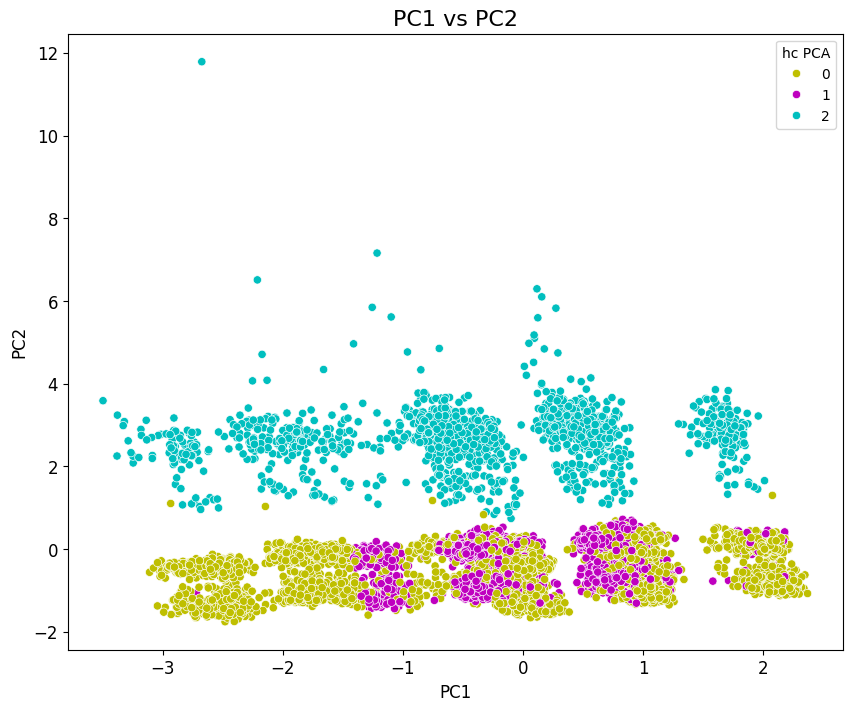

In [ ]:
# Menggunakan warna yang lebih terang
plt.figure(figsize=(10, 8))
sns.scatterplot(x=1, y=2, data=df_hc, hue='hc PCA',
    palette=['y','m','c','g']
)
plt.title('PC1 vs PC2', fontsize=16)
plt.xlabel('PC1', fontsize=12)
plt.ylabel('PC2', fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt

##Comparison

In [ ]:
def create_comparison_table(data, kmeans_model, hierarchical_model, dbscan_labels):

    # K-Means
    kmeans_silhouette = silhouette_score(data, kmeans_model.labels_, metric='manhattan')
    kmeans_ch = calinski_harabasz_score(data, kmeans_model.labels_)
    kmeans_db = davies_bouldin_score(data, kmeans_model.labels_)

    # Hierarchical
    hierarchical_silhouette = silhouette_score(data, hierarchical_model.labels_, metric='manhattan')
    hierarchical_ch = calinski_harabasz_score(data, hierarchical_model.labels_)
    hierarchical_db = davies_bouldin_score(data, hierarchical_model.labels_)

    # DBSCAN (exclude noise)
    mask = dbscan_labels != -1

    dbscan_silhouette = silhouette_score(
        data[mask],
        dbscan_labels[mask],
        metric='manhattan'
    )

    dbscan_ch = calinski_harabasz_score(
        data[mask],
        dbscan_labels[mask]
    )

    dbscan_db = davies_bouldin_score(
        data[mask],
        dbscan_labels[mask]
    )

    comparison_table = pd.DataFrame({
        'Metric': [
            'Silhouette Score',
            'Calinski-Harabasz Index',
            'Davies-Bouldin Index'
        ],
        'K-Means Clustering': [
            kmeans_silhouette,
            kmeans_ch,
            kmeans_db
        ],
        'Hierarchical Clustering': [
            hierarchical_silhouette,
            hierarchical_ch,
            hierarchical_db
        ],
        'DBSCAN': [
            dbscan_silhouette,
            dbscan_ch,
            dbscan_db
        ]
    })

    return comparison_table

In [ ]:
comparison_table = create_comparison_table(
    X_scaled,
    kmeans_pca,
    model,
    labels
)
comparison_table